# Residency-6: Project-1 | NeuralNetwork&DL_R6 | Jayant Ojha

## Problem statement
This project has 2 case studies. The first case study (described below - 30 points) covers concepts taught in Part 1 (first 8 hours of Neural networks basics).
1st case study - Project 1:

Given a Bank customer, can we build a classifier which can determine whether they will leave or not using Neural networks?

### Dataset

The case study is from an open source dataset from Kaggle. 
 
Dataset Link - https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling 


In [323]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [324]:
import pathlib as pth
import shutil, re
from os import path, unlink, listdir
import math
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, KFold
from scipy import stats
from sklearn import metrics
from sklearn import preprocessing
from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import tensorflow as tf
np.random.seed(42)
tf.set_random_seed(42)
tf.__version__
tf.keras.__version__
tf.reset_default_graph()

'1.14.0'

'2.2.4-tf'

In [325]:
# Root directory for the project
#            ***VERY URGENT NOTE***
# 1. first, PLEASE CREATE THE "data"("temp_data" within this) & "plots" FOLDERS AT
#    THE SAME LEVEL, WHERE THE IPYNB FILE IS.
# 2. WHILE YOU PASTE THIS CODE TO IPYNB-environment,
#    PLEASE USE THE BELOW COMMENTED LINE, IN THAT CASE
PRJ_ROOT_DIR = r"{}\\".format(pth.Path.cwd())
# IF YOU ARE RUNNING THIS CODE, in say, PYCHARM-ENV
# USE THE LINE BELOW FOR "PRJ_ROOT_DIR"
#PRJ_ROOT_DIR = r"{}\..\\".format(pth.Path.cwd())
# Data-Set path (assuming, data set will be @ the "data" folder
# under a project root.
DATA_SET_PATH = r"{}\\data\\".format(PRJ_ROOT_DIR)
DATA_SET_XLS_PATH = r"{}\data\park_df.xlsx".format(PRJ_ROOT_DIR)

#             **URGENT NOTE**
# AS THIS PARTICULAR IPYNB INTENDS TO SHOW USAGE OF impute_rows_null_cols()
# WHERE IT BECOMES BETTER USING A DATASET WHICH ACTUALLY HAS THE MISSING
# ELEMENTS.HENCE THE BELOW LINE HAS BEEN SELECTED.
# ALSO IMPORTANT TO NOTE, IS A RELATED CHANGE IN THE get_data_summary() defn.
# RELATED TO read_data & change in DATA_SET_CSV_PATH CHOICE BELOW.

# Below data is provided as text file, with separate, user-supplied col_names
# DATA_SET_CSV_PATH = r"{}\data\pima-indians-diabetes.data".format(PRJ_ROOT_DIR)
# Below data is provided as csv file, with col-names already there.
DATA_SET_CSV_PATH = r"{}\data\bank.csv".format(PRJ_ROOT_DIR)
DBG_FILES = True
IPYNB_ENV = True
DESIRED_LINE_WIDTH = 800
DESIRED_MAX_COLUMNS = 100

In [326]:
def quant_attrib_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20, clean_current=False, file_postfix=None):
    """
    The following function is being written to plot the "individual" & "detailed" spread of the histogram for only the
    quantitative features alone.Here, the default "cut-points" value is 40. All the "quantitative" features alone(which
    actually are, all of them, for the sample data above) are selected by using the "describe" data-frame.Then it loops
    through individual features, and the feature-min to feature-max is divided into the cut-points (default 40)& plotted
    in turn. Many of the features may show outliers (on a z-score, seen separately using the commented line, with
    "normed" option below with up to  z= +3.0 & beyond)
    :param clean_current:
    :param file_postfix:
    :param df:
    :param cut_pts:
    :param fig_height:
    :param fig_len:
    """
    descr_df = df.describe().loc[['min', 'max'], :]  # , 'count', 'mean', 'std']
    if clean_current:
        remove_files(PLOT_PATH)
    if DBG_FILES:
        print("*********************************************************************************")
        print(" ***PLS LOOK INTO FOLLOWING PLOT FILES TO DECIDE BEFORE/AFTER EFFECTS:***")
    for feature in list(descr_df.T.index):
        bins = np.linspace(descr_df[feature]['min'], descr_df[feature]['max'], cut_pts)
        pyplot.subplots(figsize=(fig_len, fig_height))
        if not IPYNB_ENV:
            # pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature))
            pyplot.hist(df[feature], bins, alpha=0.5, label=str(feature))
            pyplot.legend(loc='upper right')
            fname = PLOT_PATH + "{0}_{1}.png".format(feature, file_postfix)
            pyplot.savefig(fname)
            if path.exists(fname):
                if DBG_FILES:
                    print(path.abspath(fname))
            else:
                print("file not found")
            pyplot.close(pyplot.gcf())
        else:
            legend_name = "{0}_{1}.png".format(feature, file_postfix)
            # pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(legend_name))
            pyplot.hist(df[feature], bins, alpha=0.5, label=str(legend_name))
            pyplot.legend(loc='upper right')
            pyplot.show()
    if DBG_FILES:
        print("*********************************************************************************")


def get_all_num_cols(df, verbose=False):
    """
    This routine returns the list of all numeric columns, in a pandas dataframe.This list is a possible mix of both
    null & non-null columns
    :param verbose:
    :param df:
    :return: list
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if verbose:
        print("*********************************************************************************")
        print("The list of all NUMERIC-COLUMNS is {}".format(num_cols))
        print("*********************************************************************************")
    return num_cols


def get_null_num_cols(df, verbose=False):
    """
    This routine returns the list of all null-numeric columns, in a pandas dataframe.This list only has the null
    numeric columns.
    :param verbose:
    :param df:
    :return: list
    """
    null_num_cols = [x for x in get_all_num_cols(df) if df[x].isnull().any()]
    if verbose:
        print("*********************************************************************************")
        print("The list of all **NULL** NUMERIC-COLUMNS is {}".format(null_num_cols))
        print("*********************************************************************************")
    return null_num_cols


def get_all_non_num_cols(df, verbose=False):
    """
    This routine returns the list of all non-numeric columns, in a pandas dataframe.This list is a possible mix of both
    null & non-null columns
    :param verbose:
    :param df:
    :return: list
    """
    non_num_cols = [x for x in list(df.columns) if x not in get_all_num_cols(df)]
    if verbose:
        print("*********************************************************************************")
        print("The list of all NON-NUMERIC-(OBJECT-TYPE)-COLUMNS is {}".format(non_num_cols))
        print("*********************************************************************************")
    return non_num_cols


def get_null_non_num_cols(df, verbose=False):
    """
    This routine returns the list of all null-non-numeric columns, in a pandas dataframe.This list just has the
    "object" columns which have some potential null values
    :param verbose:
    :param df:
    :return: list
    """
    null_non_num_cols = [x for x in get_all_non_num_cols(df) if pd.to_numeric(df[x], errors='coerce').isnull().any()]
    tmp_df = df.copy()
    if verbose:
        print("*********************************************************************************")
    for col in null_non_num_cols:
        tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
        x = tmp_df[[col]].describe(include='all').loc['mean', col]
        if math.isnan(x):
            if verbose:
                print(f"The NON-NUMERIC-(OBJECT-TYPE)-COLUMN:'{col}'' is a FULL-FLEDGED OBJECT-TYPE")
                print("       **This col:'{}' will require a different treatment**    ".format(col))
            null_non_num_cols.remove(col)
    if verbose:
        print("*********************************************************************************")
        print("*********************************************************************************")
        print("The list of all **NULL** NON-NUMERIC-(OBJECT-TYPE)-COLUMNS is {}".format(null_non_num_cols))
        print("*********************************************************************************")
    return null_non_num_cols


def display_rows_null_num_cols(df):
    """
    This routine prints out the rows, w.r.t. the null-numeric column (one at a time)
    :param df:
    :return: list
    """
    for col in get_null_num_cols(df):
        print("*********************************************************************************")
        print("Following dataframe rows has NULL values, for the NUMERIC column: {}".format(col))
        print("*********************************************************************************")
        print(df[pd.to_numeric(df[col]).isnull()])


def display_rows_null_non_num_cols(df):
    """
    This routine prints out the rows, w.r.t. the null-non-numeric column (one at a time)
    :param df:
    :return: list
    """
    for col in get_null_non_num_cols(df):
        print("*********************************************************************************")
        print("Following dataframe rows has NULL values, for the NON-NUMERIC column: {}".format(col))
        print("*********************************************************************************")
        print(df[pd.to_numeric(df[col], errors='coerce').isnull()])


def impute_rows_null_cols(df, fill_opt_dict, clean_current=False, compare_dist=True):
    """
    This routine fills and/or drop out the rows, w.r.t. the null-numeric column (one at a time) & based-on a
    user-supplied dict of options, feature-wise.
    :param clean_current:
    :param compare_dist:
    :param fill_opt_dict:
    :param df:
    :return: list
    """
    if clean_current:
        remove_files(PLOT_PATH)
    for col in fill_opt_dict.keys():
        numeric_feature = col in get_all_num_cols(df)
        object_feature = col in get_all_non_num_cols(df)
        assert numeric_feature != object_feature
        if col not in list(df.columns):
            print("*********************************************************************************")
            print("The Fill-Option-Dict you passed, doesn't match the dataframe column @ {}".format(col))
            print("*********************************************************************************")
            assert 0
        else:
            if numeric_feature:
                print("*********************************************************************************")
                print(f"For NULL-NUMERIC column: {col}, the user-provided IMPUTE-option is: {fill_opt_dict[col]}")
                print("*********************************************************************************")
                df_slice_ref = df[pd.to_numeric(df[col]).isnull()]
            elif object_feature:
                print("*********************************************************************************")
                print(f"For NULL-NON-NUMERIC(OBJECT-TYPE)column:{col},user-provided IMPUTE-option:{fill_opt_dict[col]}")
                print("*********************************************************************************")
                df_slice_ref = df[pd.to_numeric(df[col], errors='coerce').isnull()]
                df[col] = df[[col]].apply(pd.to_numeric, errors='coerce')
            else:
                assert 0
            _fill_user_value(df, col, df_slice_ref, fill_opt_dict[col], compare_dist)
            df.to_csv(DBG_TEMP_CSV_PATH_1, na_rep='NaN', index=False, quoting=3)


def _fill_user_value(df, col, df_slice_ref, usr_opt, compare_dist):
    """
    This is a helper routine (used by the user-accessed "impute_rows_null_num_cols" to fill user values.Iteratively
    use it(thru "impute_rows_null_num_cols") to get a visual-guidance on the impact of imputation. Based on the user
    decision, after having visualized the impact of any such imputations.
    :param compare_dist:
    :param df_slice_ref:
    :param df:
    :param col:
    :param df_slice_ref:
    :param usr_opt:
    """
    if compare_dist and usr_opt != 'drop':
        quant_attrib_hist_plot(df[[col]], file_postfix="_dist_before_{}_impute_of_{}".format(usr_opt, col))
    elif compare_dist and usr_opt == 'drop':
        quant_attrib_hist_plot(df, file_postfix="_dist_before_{}_impute_of_{}".format(usr_opt, col))
    if usr_opt == 'mean':
        df[col].fillna(round(df[col].mean(), 2), inplace=True)
    elif usr_opt == 'median':
        df[col].fillna(round(df[col].median(), 2), inplace=True)
    elif usr_opt == 'drop':
        df.drop(df_slice_ref.index, inplace=True)
    else:
        # assert (str.type != float)
        df[col].fillna(round(usr_opt, 2), inplace=True)
    if compare_dist and usr_opt != 'drop':
        quant_attrib_hist_plot(df[[col]], file_postfix="_dist_after_{}_impute_of_{}".format(usr_opt, col))
    elif compare_dist and usr_opt == 'drop':
        quant_attrib_hist_plot(df, file_postfix="_dist_after_{}_impute_of_{}".format(usr_opt, col))


def read_data_set(data_path, is_text=False, usr_col_list=None):
    """
    Read the csv or excel file at a given path, into a dataframe & return the same
    :param usr_col_list:
    :param is_text:
    :param data_path:
    :return:
    """
    if data_path == DATA_SET_XLS_PATH:
        df = pd.read_excel(data_path, encoding="ISO-8859-1")
    elif is_text:
        df = pd.read_csv(DATA_SET_CSV_PATH, names=usr_col_list)
    else:
        df = pd.read_csv(data_path, encoding="ISO-8859-1")
    cleanup_column_names(df)
    col_name_full = list(df.columns)
    return df.loc[:, col_name_full]


def remove_files(files_at_path):
    """
    Simple utility to delete files and sub-folders at a given path.
    :param files_at_path:
    """
    for the_file in listdir(files_at_path):
        file_path = path.join(files_at_path, the_file)
        try:
            if path.isfile(file_path):
                unlink(file_path)
            elif path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(e)


def get_shape_info_description(df):
    """
    Give a quick summary of shape, info() & describe().T (i.e. pandas-provided dimensions, info on the feature-types
    & descriptive-stats (including "all" in a transposed way))
    :type df: pandas dataframe
    """
    pd.set_option('display.width', DESIRED_LINE_WIDTH)
    pd.set_option('display.max_columns', DESIRED_MAX_COLUMNS)
    print("*********************************************************************************")
    print("                ***First, let's EYEBALL a few RANDOM data-rows***")
    print(df.sample(n=8, random_state=7))
    print("*********************************************************************************")
    print("*********************************************************************************")
    print("                ***The SHAPE of the dataframe is: {}***".format(df.shape))
    print("*********************************************************************************")
    print("*********************************************************************************")
    print("                ***The INFO() on the dataframe is:***")
    print(df.info())
    print("*********************************************************************************")
    print("*********************************************************************************")
    print("                ***The DESCRIPTIVE-STATISTICS on the dataframe is:***")
    print(df.describe(include='all').T)
    print("*********************************************************************************")


def cleanup_column_names(df):
    """
    This routine "cleans" up the column names, in the sense that the non alphanumeric, non-word characters are
    replaced with underscore-joined names instead

    :param df:
    """
    new_col_names = []
    for col_name in df.columns:
        # Remove all non-word characters (everything except numbers and letters)
        col_name = re.sub(r"[^\w\s]", '', col_name)
        # Replace all runs of whitespace with a single dash
        col_name = re.sub(r"\s+", '_', col_name)
        new_col_names.append(col_name)
    df.rename(columns={i: j for i, j in zip(df.columns, new_col_names)}, inplace=True)


def get_data_summary(df, stop_suggest=False):
    """
    Give a quick summary of null & non-null elements.Show each row for those features.
    :param stop_suggest:
    :param df:
    """
    # Below read_data_set (with csv option) caters to a situation(identified with just one path arguments)
    # read_data_set(DATA_SET_CSV_PATH)
    # df = read_data_set(DATA_SET_CSV_PATH)
    # Below read_data_set (with csv option & additional, is_text=True arg & a user-supplied col_names
    # list ) caters to a situation with "text-data_with-no-columns"
    # df = read_data_set(DATA_SET_CSV_PATH, is_text=True, usr_col_list=['preg', 'plas', 'pres', 'skin',
    #                                                                  'test', 'mass', 'pedi', 'age', 'class'])
    get_shape_info_description(df)
    get_all_num_cols(df, True)
    get_all_non_num_cols(df, True)
    get_null_non_num_cols(df, True)
    get_null_num_cols(df, True)
    display_rows_null_num_cols(df)
    display_rows_null_non_num_cols(df)
    if not stop_suggest:
        print("*********************************************************************************")
        print("                          ***SUGGESTED STEP-1***")
        print("                ***If any NULL entries were found***")
        print("USE: <impute_rows_null_cols> routine to guide you through imputation")
        print("                  USE: <outlier_removal> if you think so. ")
        print("*********************************************************************************")
        print("                          ***SUGGESTED STEP-2***")
        print("                ***You should look at the individual distribution**")
        print("  USE: <quant_attrib_hist_plot> routine to get feature-wise distributions")
        print("*********************************************************************************")
        print("                          ***SUGGESTED STEP-3***")
        print("        *** If this is a SPVSD_LRNG_REGRESSION/CLASSIFICATION problem:  ***")
        print("***You should look at the p-value summary to decide upon dropping feature if p>0.05***")
        print("  USE: <get_p_value_feature_drop_list> routine to get such feature-list to drop")
        print("*********************************************************************************")
        print("                          ***SUGGESTED STEP-4***")
        print("                  ***You should look at the pair-plot now**")
        print("                          USE: <plot_pairplot>  ")
        print("        *** If this is a UNSPVSD_LRNG problem: refer a & b & c just below ***")
        print("*** a. Here, you should look at the diagonal distributions to anticipate clusters-numbers***")
        print("  *** b. Here, you should look at multicollinearity-signs to decide on PCA***")
        print(" *** c. Additionally, for multicollinearity-signs (to decide on PCA) use the VIF-matrix too***")
        print("                USE: <feature_vif_analysis> & <feature_vif_stepwise_removal>  ")
        print("                 *** If this is a SPVSD_LRNG_REGRESSION problem:  ***")
        print("  ***still look at a, b & c to see if Linear etc. Regression be applied on individual clusters")
        print("*********************************************************************************")
        print("                          ***SUGGESTED STEP-5***")
        print("                    *** If this is a SPVSD_LRNG problem:***")
        print("  ***You should look at the correlation-matrix heatmap & get a sorted-descending-list of:***")
        print("               ***feature-corr-values w.r.t. the dependent-variable ***")
        print("  USE:  <plot_correlation_heatmap> routine to get visual-correlation matrix")
        print("  USE:  <get_sorted_corr_list> routine to get such feature-list to probably use for forward-selection")
        print("*********************************************************************************")


def select_features(df, user_exclude_list):
    """
    Select the features by providing the dataframe & a list_to_drop feature-set.
    :param user_exclude_list:
    :param df:
    :return:
    """
    return [x for x in list(df.columns) if x not in user_exclude_list]


def plot_correlation_heatmap(df, user_exclude_list=None):
    """
    Plot the correlation-heatmap for the passed dataframe, while REMOVING the features in the
    "user_exclude_list' parameter.
    :param user_exclude_list:
    :param df:
    """
    if user_exclude_list is not None:
        features = select_features(df, user_exclude_list)
    else:
        features = list(df.columns)
    mask = np.zeros_like(df[features].corr(), dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True
    pyplot.subplots(figsize=(15, 10))
    pyplot.title('Pearson Correlation Matrix', fontsize=25)
    sns.heatmap(df[features].corr(), annot=True, linewidths=0.25, vmax=0.7, square=True, linecolor='w',
                annot_kws={"size": 8}, mask=mask, cbar_kws={"shrink": .9})
    pyplot.show()


def plot_pairplot(df, user_exclude_list=None):
    """
    Plot the pair-plot for the passed dataframe, while REMOVING the features in the
    "user_exclude_list' parameter.
    :param user_exclude_list:
    :param df:
    """
    if user_exclude_list is not None:
        features = select_features(df, user_exclude_list)
    else:
        features = list(df.columns)
    sns.pairplot(df[features], diag_kind='kde')
    pyplot.show()


def get_p_value_feature_drop_list(df, dep_var, user_exclude_list, alpha=0.05, show_summary=True):
    """
    Return the feature-list, which show a p-value> alpha (0.05, default). This list of features fail to reject the
    null hypothesis & hence first direct candidates for removal.
    :param show_summary:
    :param df:
    :param dep_var:
    :param user_exclude_list:
    :param alpha:
    """
    if user_exclude_list is not None:
        features = select_features(df, user_exclude_list)
    else:
        features = list(df.columns)
    # features = select_features(df, user_exclude_list)
    str1 = "+".join(features)
    str1 = dep_var + '~' + str1
    model = smf.ols(str1, df).fit()
    mdl_smry = model.summary()
    results_as_html = mdl_smry.tables[1].as_html()
    df_tmp = pd.read_html(results_as_html, header=0, index_col=0)[0]
    if show_summary:
        print(mdl_smry)
    return list(df_tmp.loc[df_tmp["P>|t|"] > alpha].index)


def dataframe_column_drop(df, user_exclude_list):
    """
    This routine is used to drop feature-list provided by the user
    :param df:
    :param user_exclude_list:
    :return:
    """
    if user_exclude_list is not None:
        for col in user_exclude_list:
            df = df.drop(col, axis=1)
    return df


def get_standard_scaled(df, user_exclude_list=None, dep_var=None, compare_dist=True):
    """
    Get the Standard-Scaled dataframe from the user-supplied one.
    :return:
    :param compare_dist:
    :return:
    :param df:
    :param user_exclude_list:
    :param dep_var:
    """
    df = dataframe_column_drop(df, dep_var)
    if user_exclude_list is not None:
        features = select_features(df, user_exclude_list)
    else:
        features = list(df.columns)
    if compare_dist:
        quant_attrib_hist_plot(df[features], file_postfix="_BEFORE_STD_SCALER", clean_current=True)
    scaler = preprocessing.StandardScaler()
    df_tmp = pd.DataFrame(scaler.fit_transform(df[features].values), columns=df[features].columns,
                          index=df[features].index)
    if compare_dist:
        quant_attrib_hist_plot(df_tmp[features], file_postfix="_AFTER_STD_SCALER")

    return df_tmp




## Question 1
Read the dataset

In [327]:
# Read Data
df = read_data_set(DATA_SET_CSV_PATH)

In [328]:
get_data_summary(df, stop_suggest=True)

*********************************************************************************
                ***First, let's EYEBALL a few RANDOM data-rows***
      RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
1977       1978    15585901   Johnson          717     Spain    Male   35       1       0.00              3          0               0        174770.14       1
3880       3881    15726945   Andreev          677    France  Female   72       8       0.00              2          1               1        153604.44       0
52           53    15683553   O'Brien          788    France  Female   33       5       0.00              2          0               0        116978.19       0
2551       2552    15631310     Hsieh          537    France  Female   53       3       0.00              1          1               1         91406.62       0
2246       2247    15800326     Poole          717  

*** From above automated summary, it seems:

1. Numeric columns ['RowNumber', 'CustomerId'] can be dropped

2. Categorical columns ['Surname', 'Geography', 'Gender'] should be converted to Numeric Labels

3. while the Numeric columns (which is a mix of continuous numeric, pre-numeric-converted categorical like: HasCrCard, IsActiveMember, NumOfProducts  etc): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'] are independent variables (we will do more analysis to drop or not later)

4. The Numeric column: ['Exited'] is the Dependent variable here
5. None of these columns have a missing value (so no imputation etc requirements)

## Question 2
Drop the columns which are unique for all users like IDs (5 points)

In [329]:
# Based on one of the conclusions from Question1 above
drop_list = ['RowNumber', 'CustomerId']
df = dataframe_column_drop(df, user_exclude_list=drop_list)

In [330]:
# Also, based on the concusion above, the follwong are converted
# to the numeric equivalents
col_categorical = ['Surname', 'Geography', 'Gender']
number = LabelEncoder()
for col in col_categorical:
    df[col] = number.fit_transform(df[col].astype('str'))
get_data_summary(df, stop_suggest=True)

*********************************************************************************
                ***First, let's EYEBALL a few RANDOM data-rows***
      Surname  CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
1977     1334          717          2       1   35       1       0.00              3          0               0        174770.14       1
3880       81          677          0       0   72       8       0.00              2          1               1        153604.44       0
52       1983          788          0       0   33       5       0.00              2          0               0        116978.19       0
2551     1232          537          0       0   53       3       0.00              1          1               1         91406.62       0
2246     2198          717          2       0   39       6       0.00              2          1               0         93275.61       0
270       759          650    

*** We notice above that the dataframe is in appropriate numeric form

*** Now plot each of the dataset column distributions (standard scaled, to get a glimpse of z-score based outliers for each, if any)

*********************************************************************************
 ***PLS LOOK INTO FOLLOWING PLOT FILES TO DECIDE BEFORE/AFTER EFFECTS:***


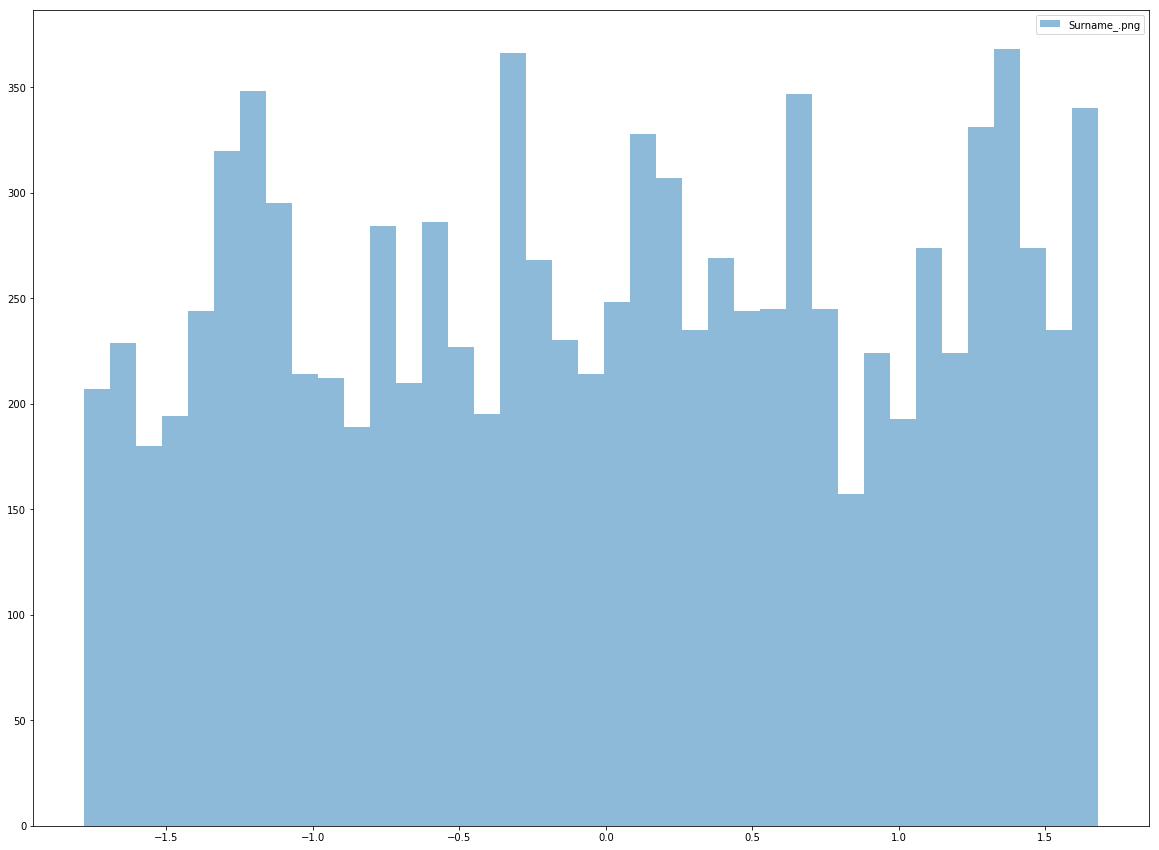

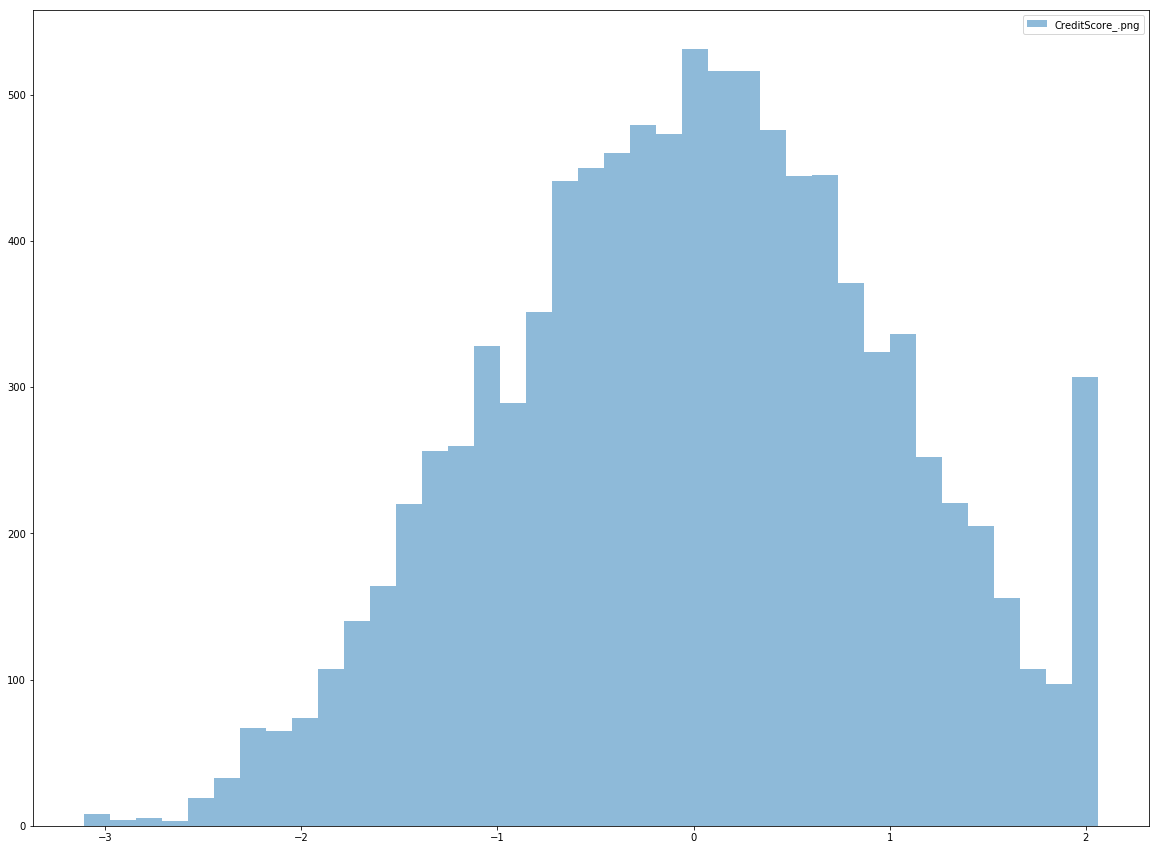

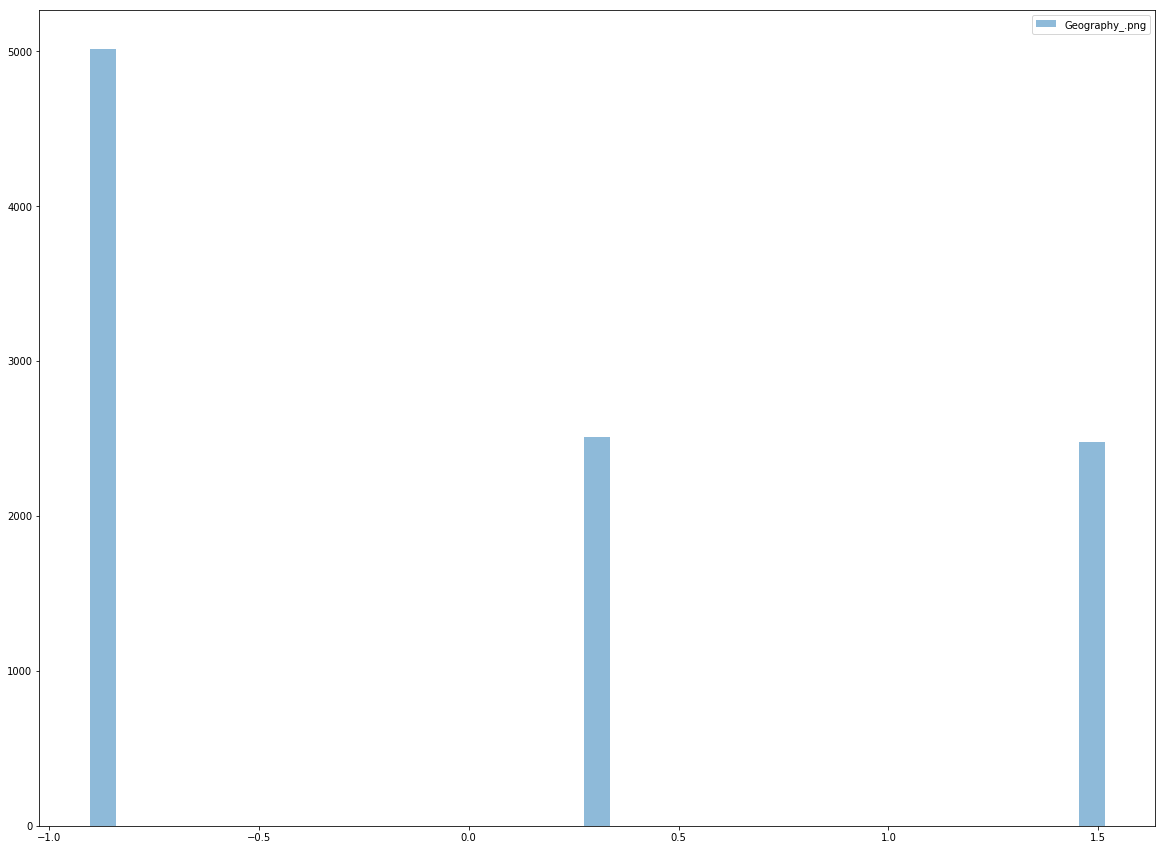

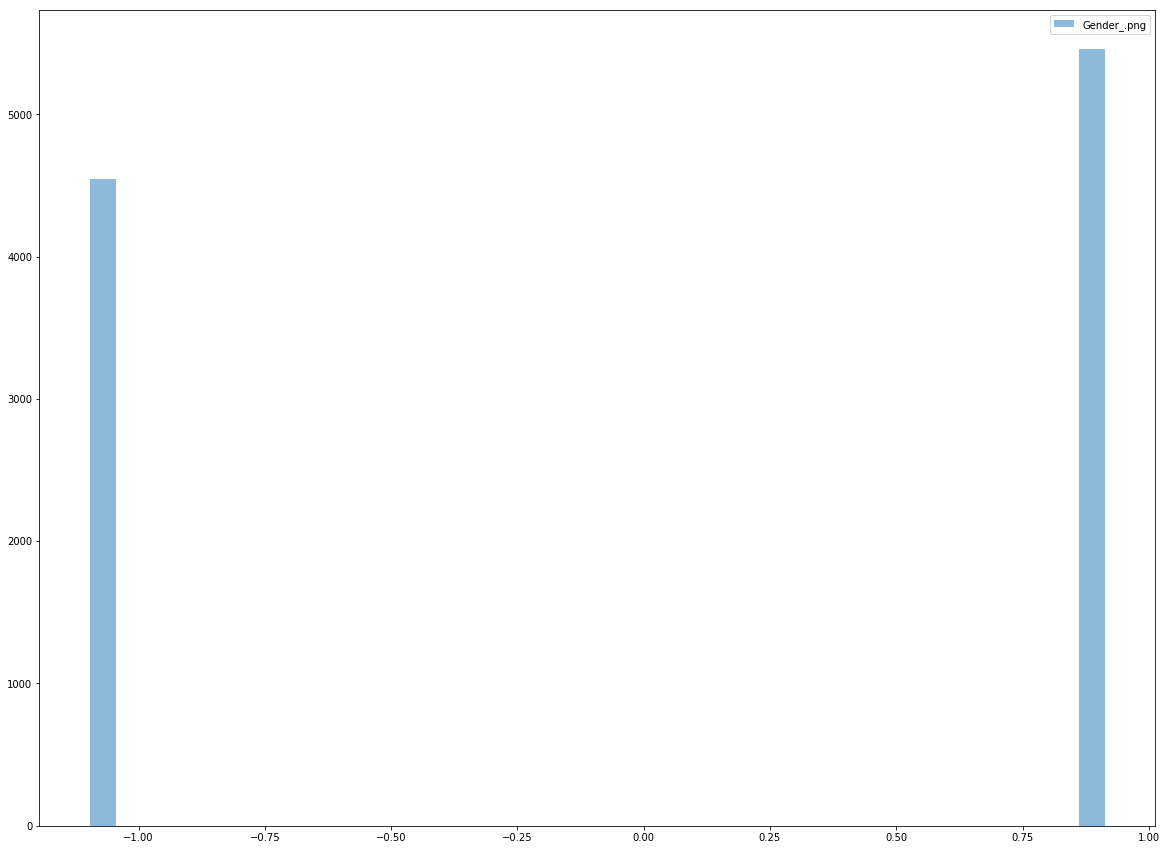

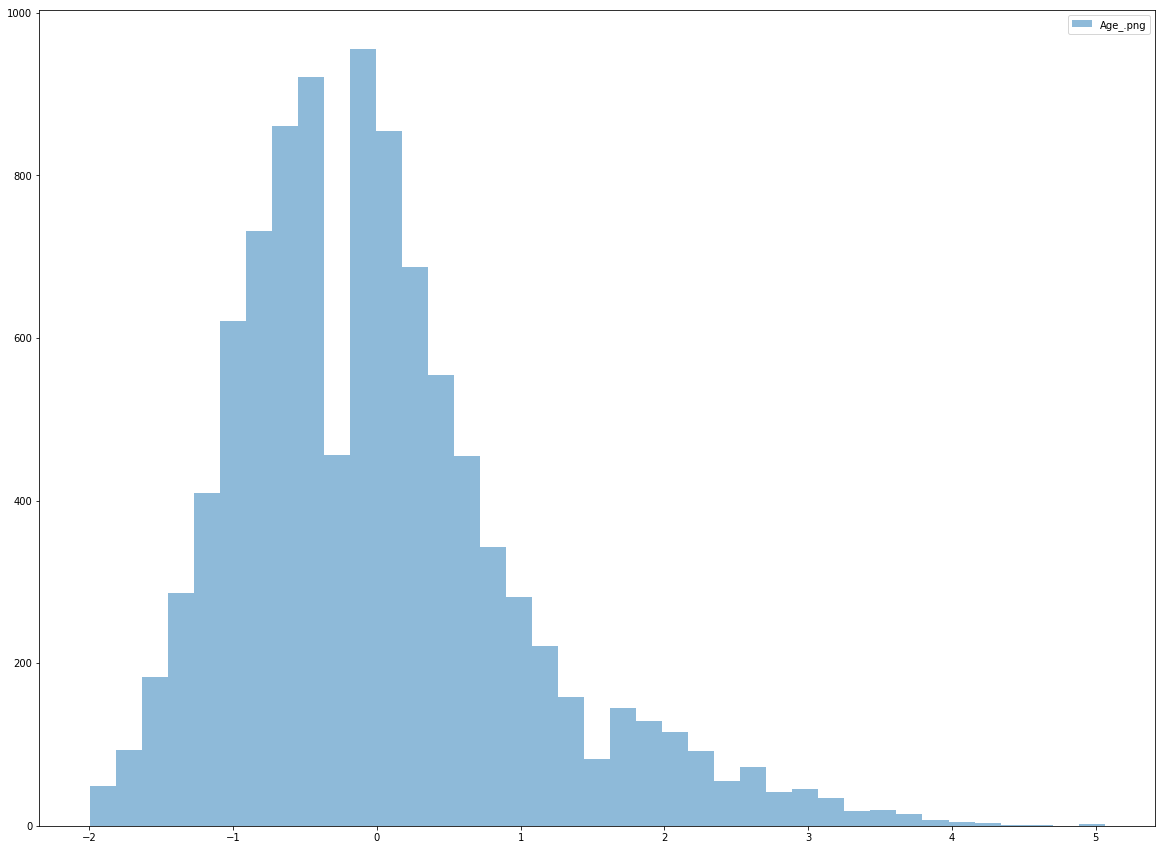

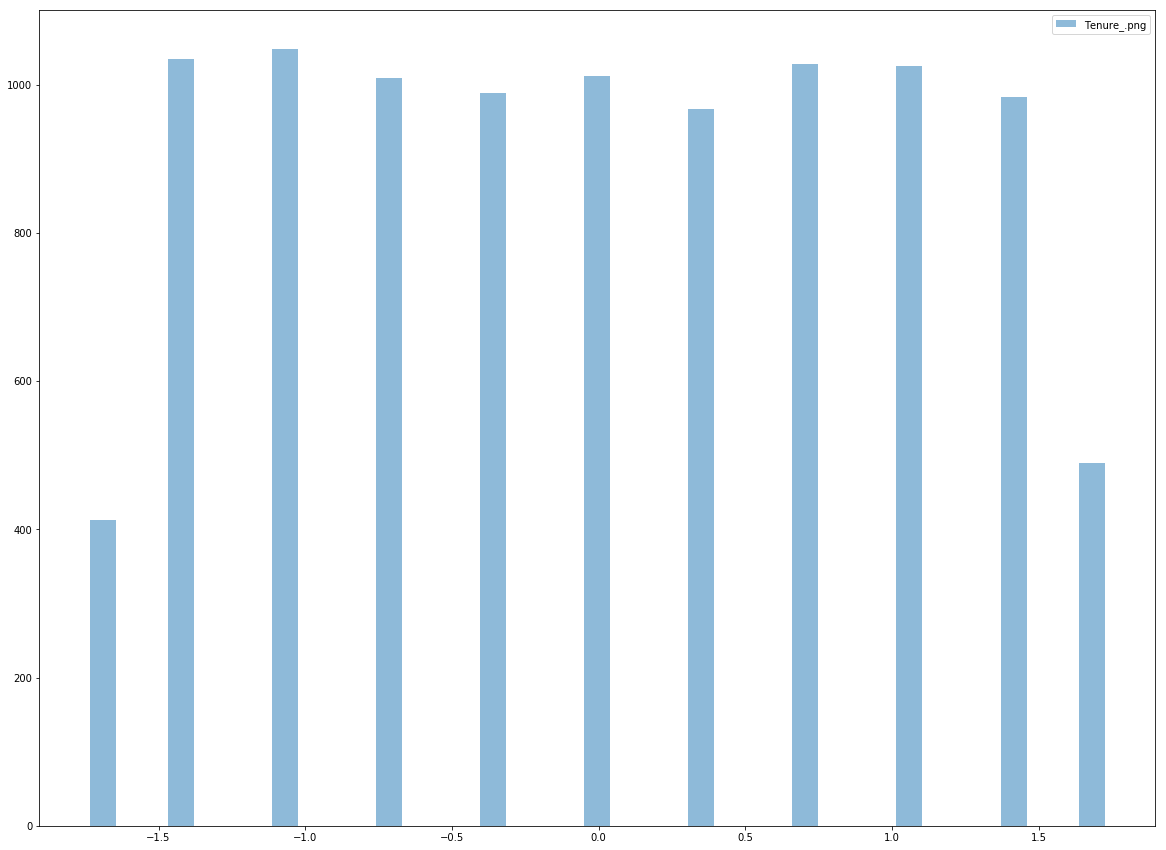

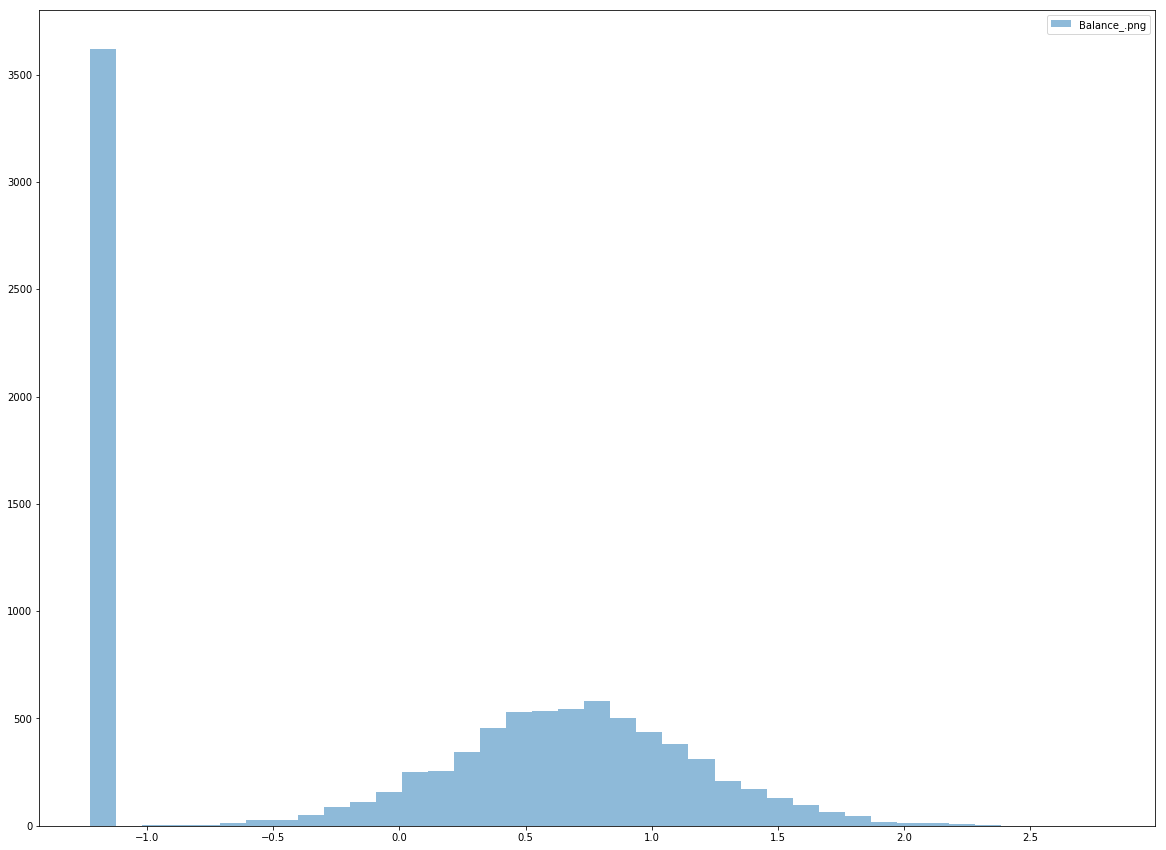

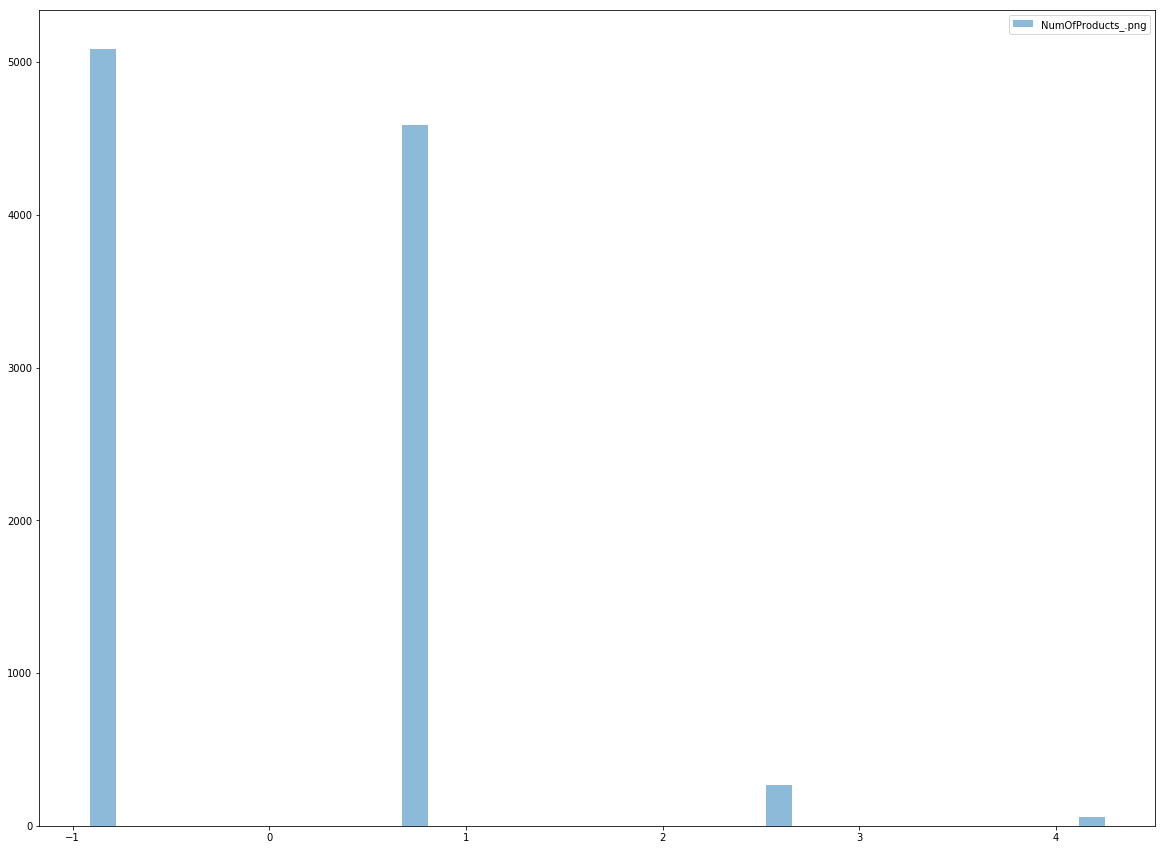

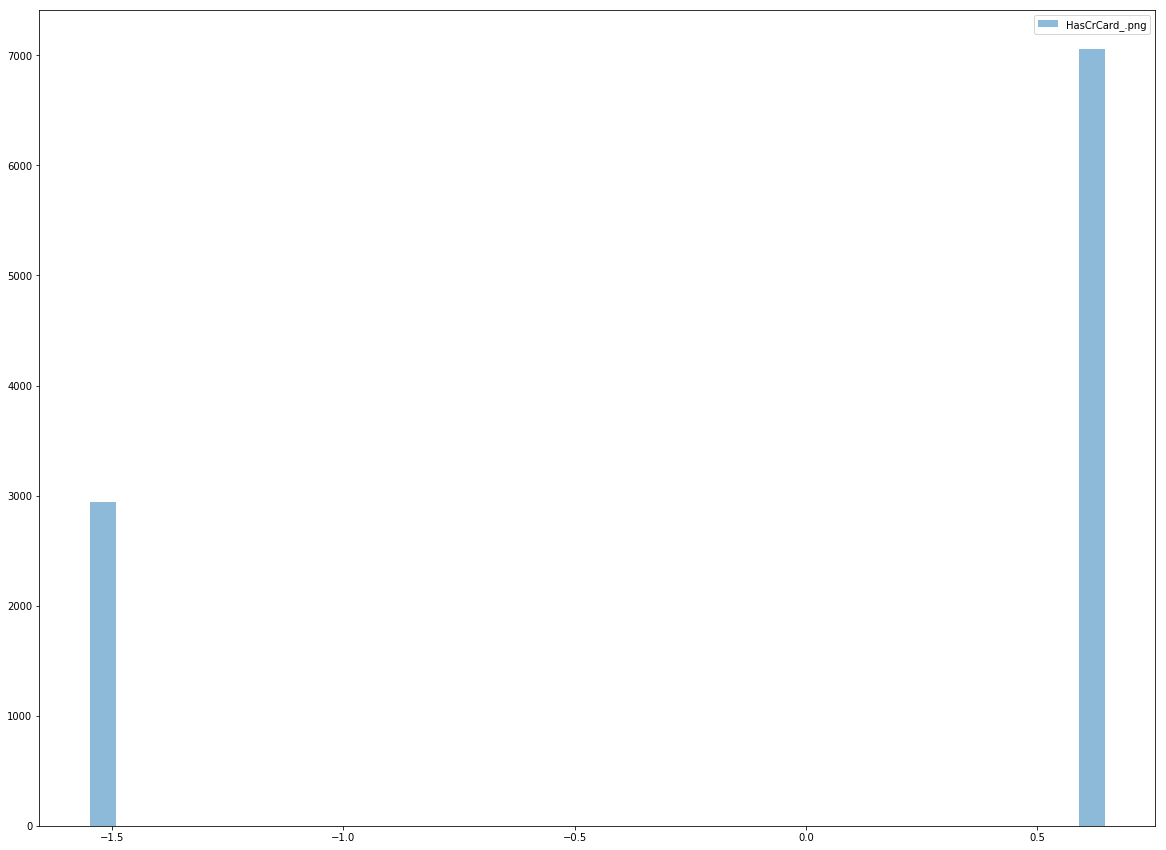

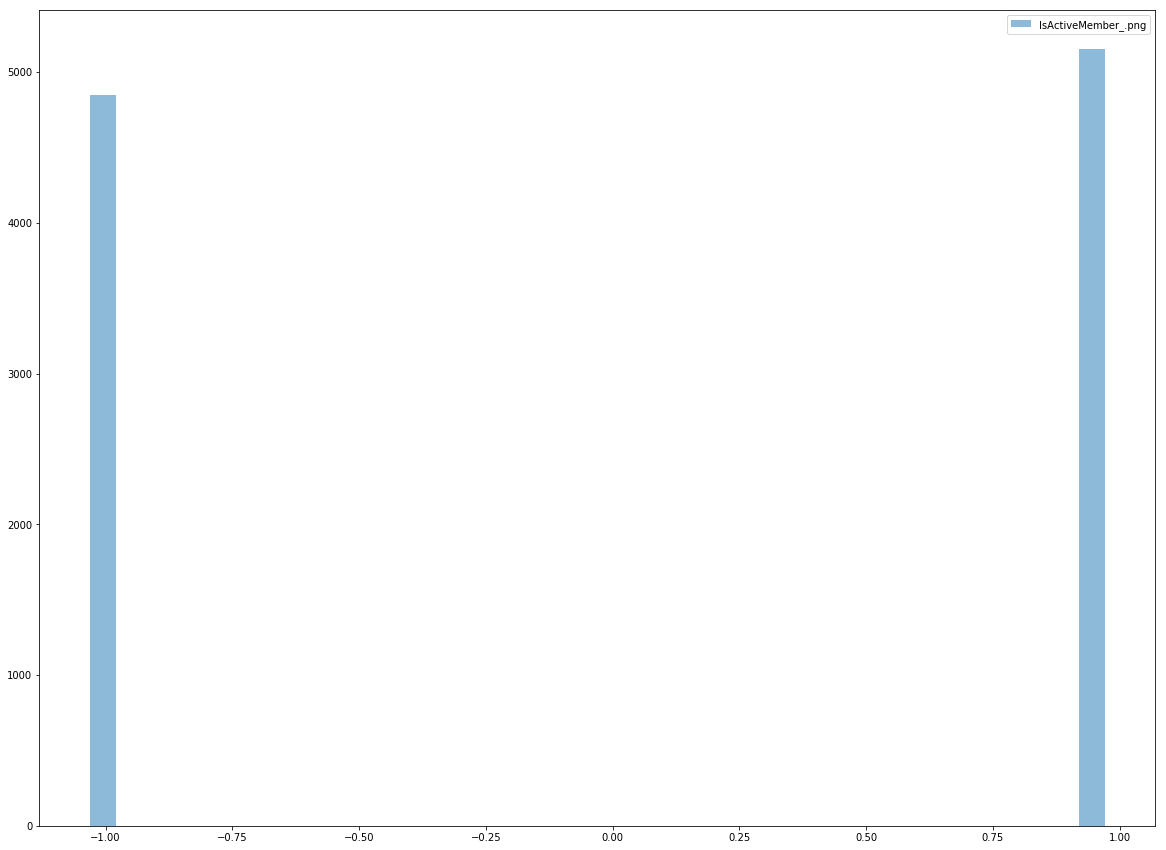

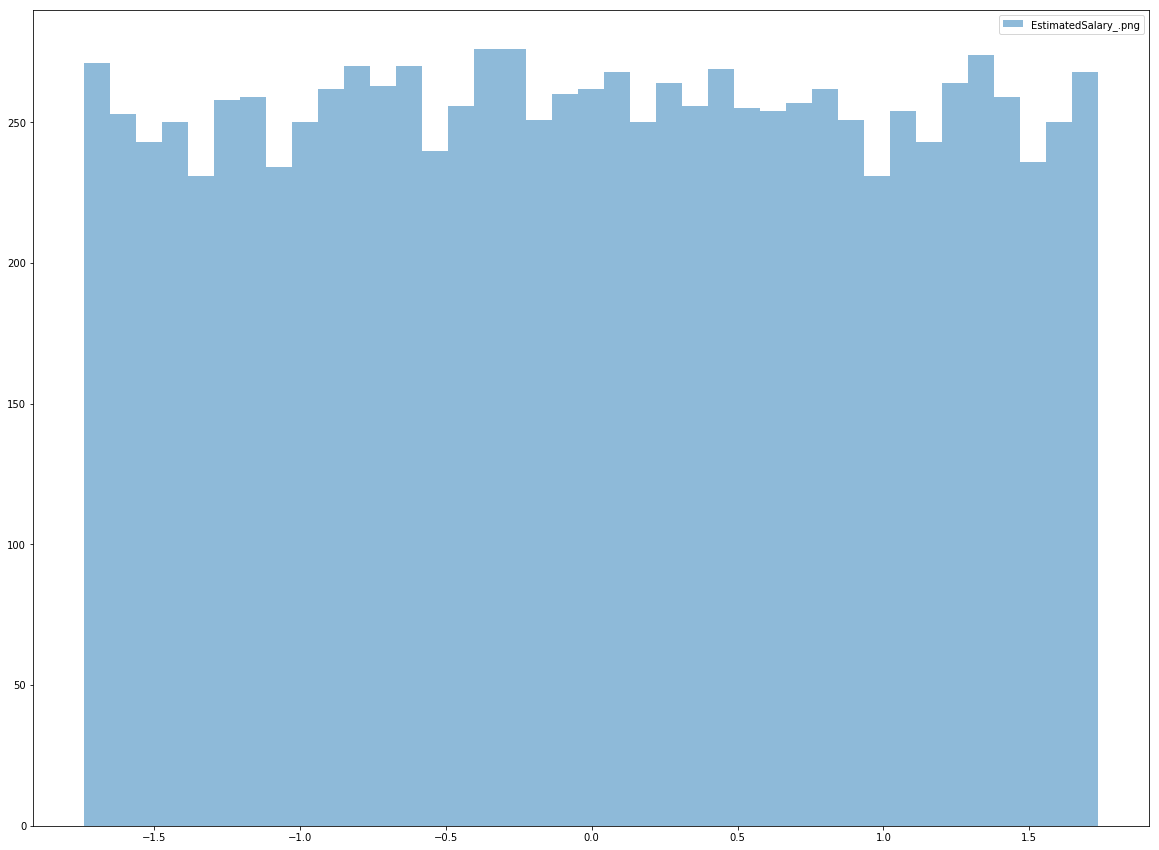

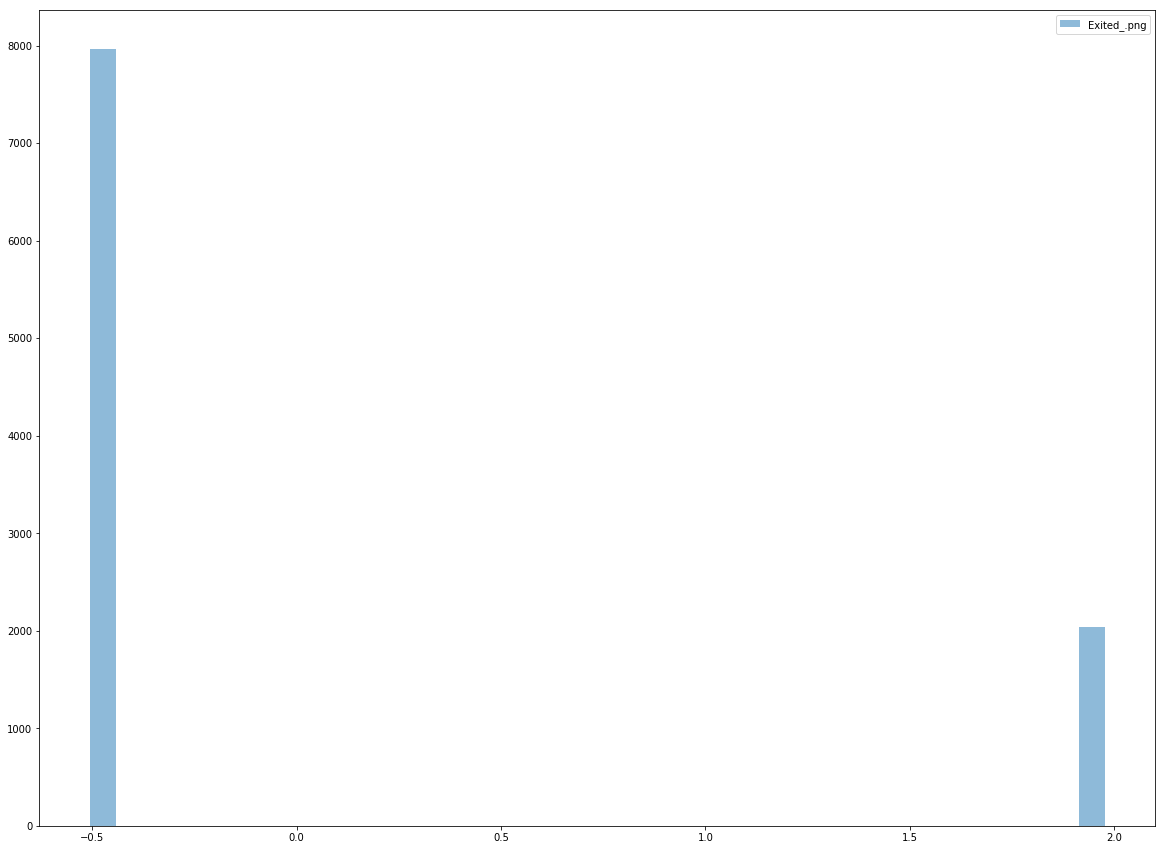

*********************************************************************************


In [331]:
quant_attrib_hist_plot(get_standard_scaled(df, compare_dist=False), file_postfix='')

***   There are no such significant outliers


*** Also the distribution for the Dependent variable "Exited" is shown below

In [332]:
print(df.groupby(["Exited"]).count())

        Surname  CreditScore  Geography  Gender   Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary
Exited                                                                                                                           
0          7963         7963       7963    7963  7963    7963     7963           7963       7963            7963             7963
1          2037         2037       2037    2037  2037    2037     2037           2037       2037            2037             2037


In [333]:
#Here is the summary of the p-values
# The "excluded variables (as they are inherently categorical or dependent variables) for this analysis  are: 
# ['Exited','Surname', 'Tenure', 'NumOfProducts', 'HasCrCard' ]
print(get_p_value_feature_drop_list(df, dep_var='Exited', user_exclude_list=['Exited','Surname', 'Tenure', 'NumOfProducts', 'HasCrCard' ]))

                            OLS Regression Results                            
Dep. Variable:                 Exited   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     225.2
Date:                Thu, 29 Aug 2019   Prob (F-statistic):          5.89e-312
Time:                        13:23:51   Log-Likelihood:                -4362.6
No. Observations:               10000   AIC:                             8741.
Df Residuals:                    9992   BIC:                             8799.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1281      0.031     

We can decide to drop the following: EstimatedSalary (p-value=0.265)     (***EDIT'ed at the end:  though, based on an iteration of score comparision, with and without[i.e. 82.23(the current one down below at the bottom) vs 80.9(previously found with similar flow), I have decided to keep this variable] ***  

In [334]:
#Decided not to drop the "EstimatedSalary" variable
#df = dataframe_column_drop(df, user_exclude_list=['EstimatedSalary'])

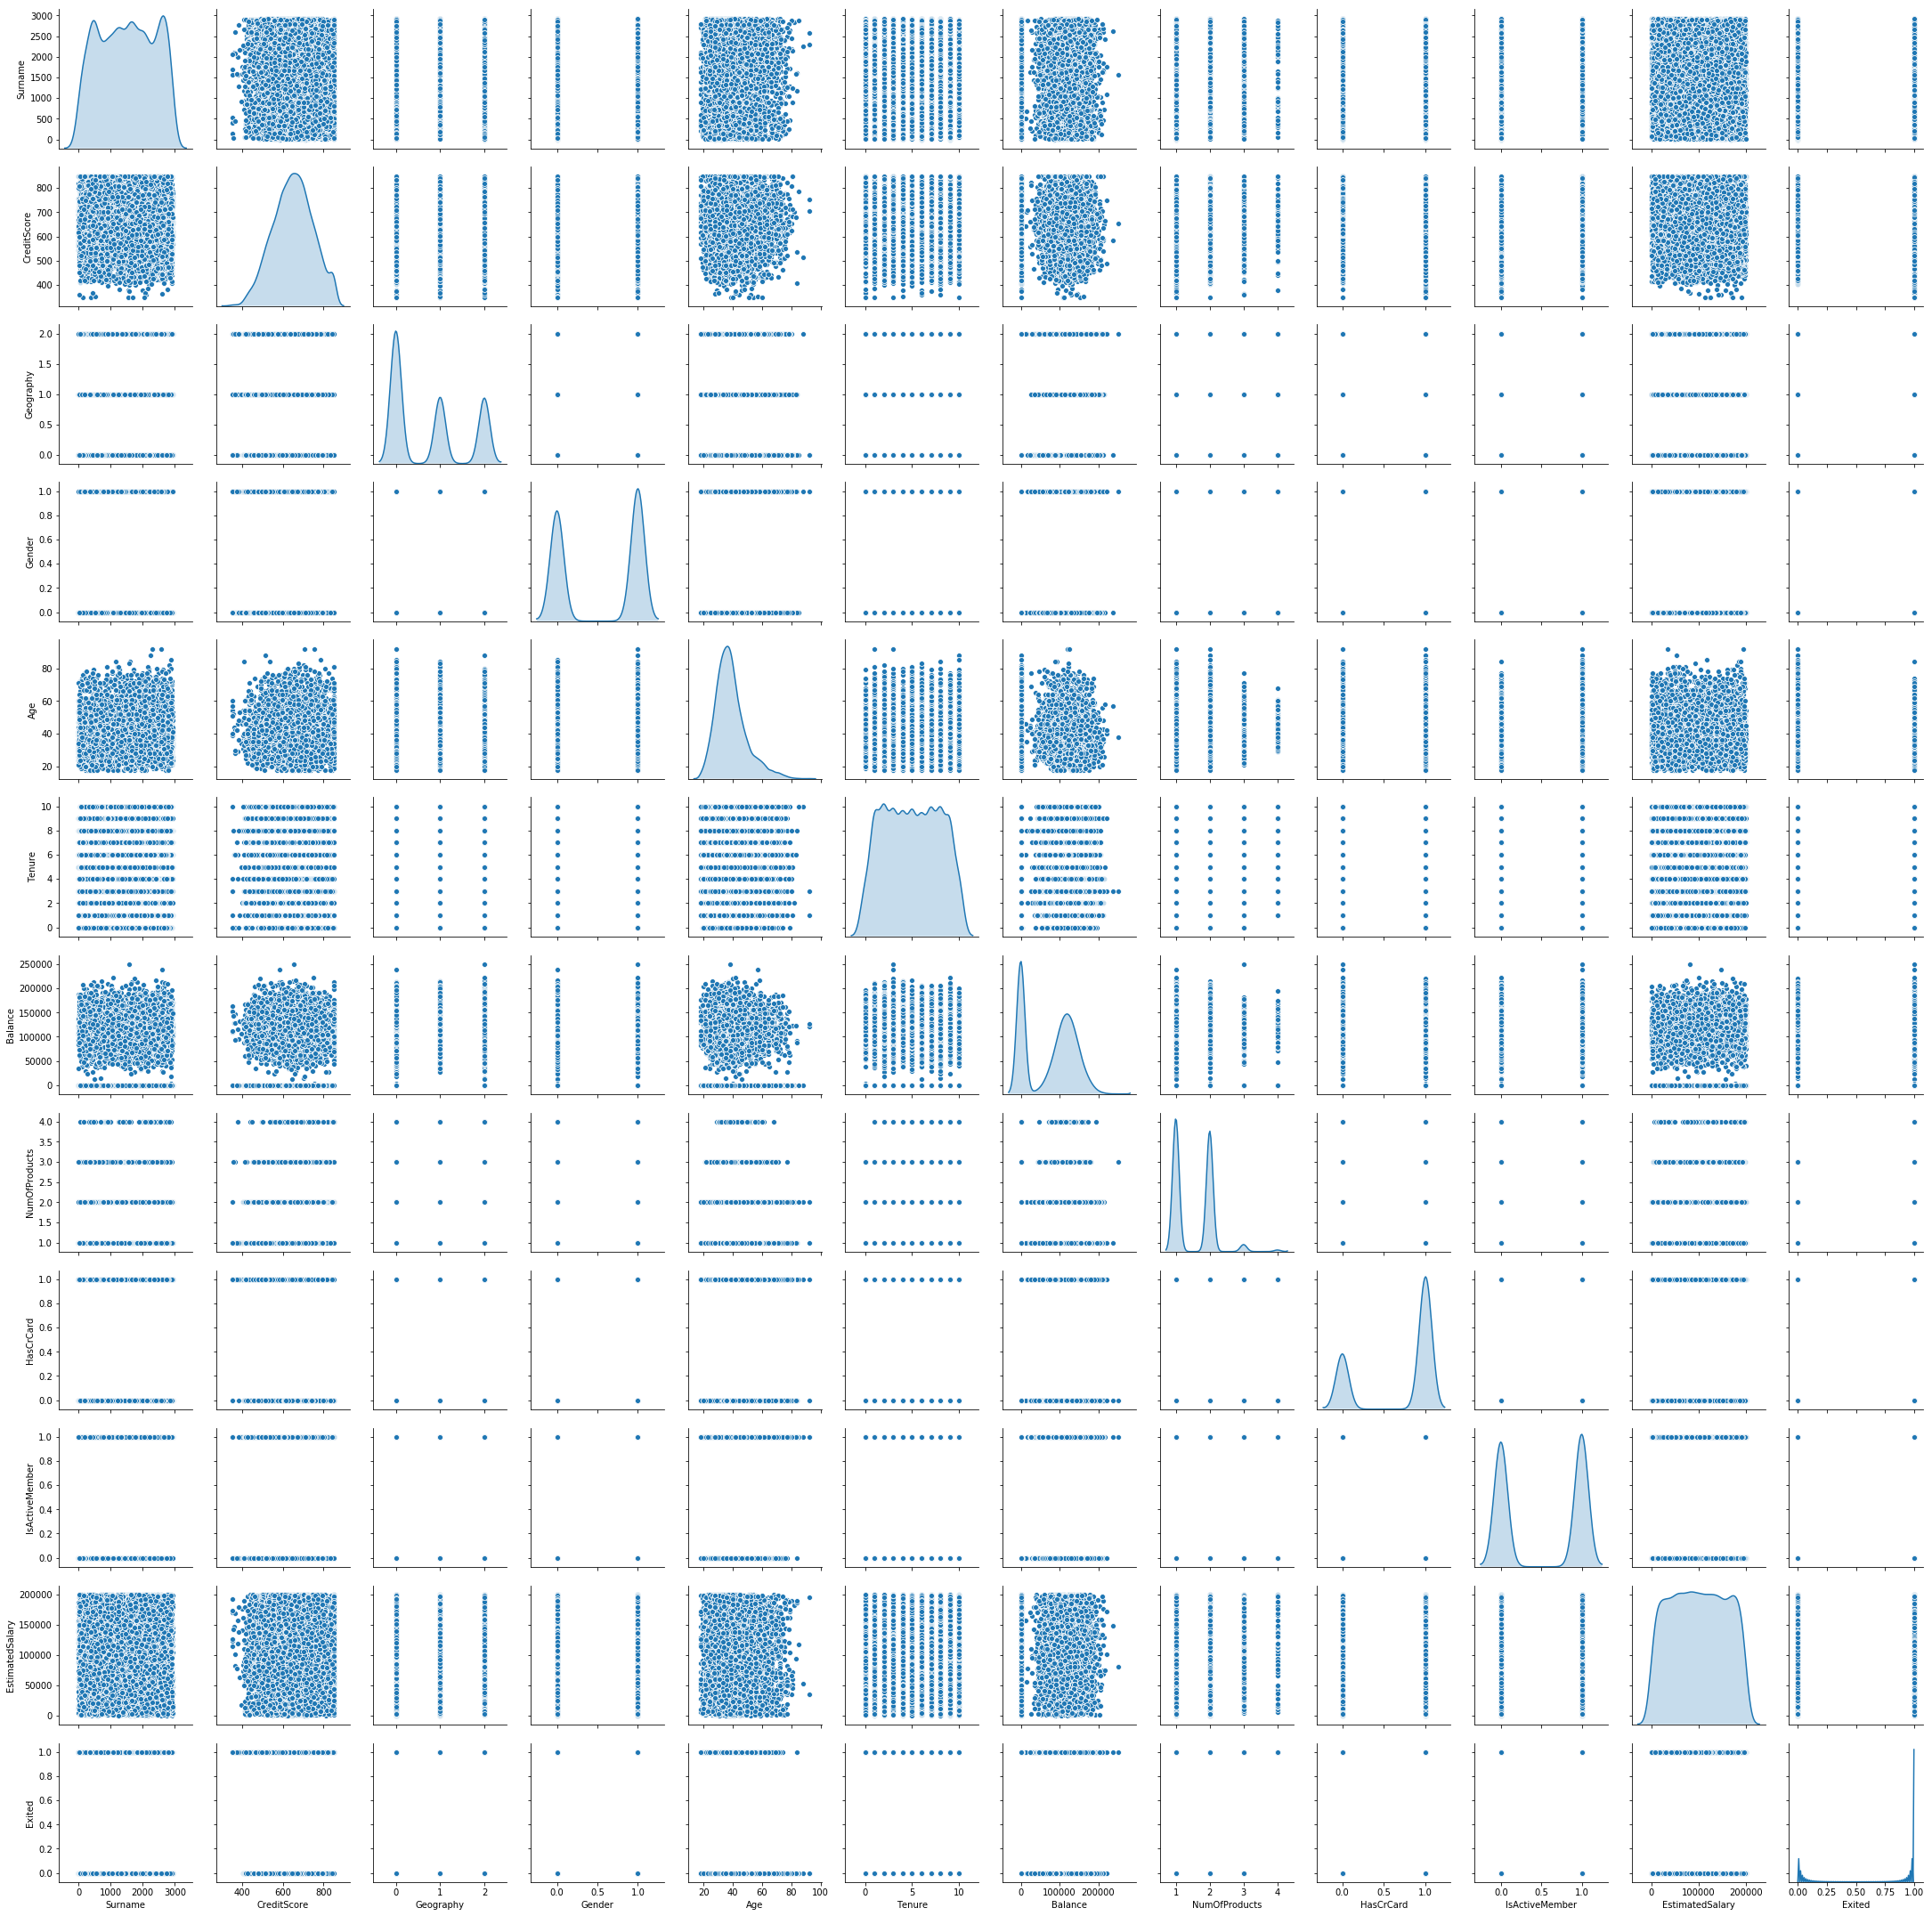

In [335]:
#we WANT TO SEE THE PAIRPLOTS, to look for any signs of multicollinearity.
plot_pairplot(df)

*** There is no multicollinearity issue seen here

## Question 3
Distinguish the feature and target set (5 points)

This has already been done in one of the steps above (under question2)

*** For Questions 4, 5, 6 & 7 ahead, here are the set of params and routines ***

In [336]:
NUM_FOLDS = 10 # Should be more than 2
RAND_SEED = 7 # Random number seeding for repeatability of the code
TEST_SIZE = 0.3   # taking 70:30 training and test set
NUM_EPOCHS = 100
NUM_CLASSES = 2 #for this classification problem(as found above)

In [337]:
def keras_nn_model(x, y, loss_func=None, optimizer=None):
    """
    A hard-coded neural-network, input_shape-250-250-250-output_onehot_class_num model
    :param x:
    :param y:
    :param loss_func:
    :param optimizer:
    :return:
    """
    tf.keras.backend.clear_session()
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(250, input_shape=(x.shape[1],), activation='relu'))
    model.add(tf.keras.layers.Dense(250, activation='relu'))
    model.add(tf.keras.layers.Dense(250, activation='relu'))
    model.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(loss=loss_func, optimizer=optimizer, metrics=['accuracy'])
    model.fit(np.array(x), np.array(y), epochs=NUM_EPOCHS, shuffle=True, verbose=2)
    return model

## Question 4
Divide the data set into Train and test sets

In [338]:
# Here the train/test split is being done into dataframe formats
# the above classifier routine: keras_nn_model uses them after
# converting to np.array
y = pd.DataFrame(np_utils.to_categorical(df.Exited), index=df.index)[range(0,NUM_CLASSES)]
df = df.drop("Exited", axis=1)
x = df    
test_size = TEST_SIZE
seed = RAND_SEED  
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=seed)

*** The cell after the Question 6 below addresses both Question 5 & 6 ***

## Question 5
Normalize the train and test data (5 points)

## Question 6
Initialize & build the model (10 points)

In [339]:
# loss function: categorical_crossentropy & optimizer: adam
fit_model = keras_nn_model(get_standard_scaled(x_train, compare_dist=False), y_train, loss_func='categorical_crossentropy', optimizer='adam')
y_predict = fit_model.predict(get_standard_scaled(x_test, compare_dist=False))
_, model_score = fit_model.evaluate(get_standard_scaled(x_test, compare_dist=False), y_test)

Epoch 1/100
7000/7000 - 1s - loss: 0.4014 - acc: 0.8370
Epoch 2/100
7000/7000 - 0s - loss: 0.3557 - acc: 0.8531
Epoch 3/100
7000/7000 - 0s - loss: 0.3452 - acc: 0.8590
Epoch 4/100
7000/7000 - 0s - loss: 0.3322 - acc: 0.8631
Epoch 5/100
7000/7000 - 0s - loss: 0.3276 - acc: 0.8673
Epoch 6/100
7000/7000 - 0s - loss: 0.3211 - acc: 0.8696
Epoch 7/100
7000/7000 - 0s - loss: 0.3128 - acc: 0.8707
Epoch 8/100
7000/7000 - 0s - loss: 0.3053 - acc: 0.8729
Epoch 9/100
7000/7000 - 0s - loss: 0.2979 - acc: 0.8760
Epoch 10/100
7000/7000 - 0s - loss: 0.2898 - acc: 0.8823
Epoch 11/100
7000/7000 - 0s - loss: 0.2836 - acc: 0.8823
Epoch 12/100
7000/7000 - 0s - loss: 0.2729 - acc: 0.8859
Epoch 13/100
7000/7000 - 0s - loss: 0.2617 - acc: 0.8950
Epoch 14/100
7000/7000 - 0s - loss: 0.2514 - acc: 0.8946
Epoch 15/100
7000/7000 - 0s - loss: 0.2399 - acc: 0.9013
Epoch 16/100
7000/7000 - 0s - loss: 0.2267 - acc: 0.9036
Epoch 17/100
7000/7000 - 0s - loss: 0.2212 - acc: 0.9049
Epoch 18/100
7000/7000 - 0s - loss: 0.20

## Question 7
Print the Accuracy score and confusion matrix (5 points)

In [340]:
print("The train/test split accuracy score from above: {}".format(model_score))

The train/test split accuracy score from above: 0.8223333358764648


In [341]:
y_pred = []
# Below y_predict is an output from fit_model.predict, which comes in form
# of an ndarray of probabilites.Each row for such array is being converted
# to list elements: 0/1, which will be acceptable by sklearn routines like
# metrics.confusion_matrix, metrics.confusion_matrix etc.
for val in y_predict:
    y_pred.append(np.argmax(val))
ytest = []
for val in np.array(y_test):
    ytest.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(ytest,y_pred)
print(cm)

[[2166  229]
 [ 304  301]]


In [342]:
acc=metrics.accuracy_score(ytest,y_pred)
print(acc)


0.8223333333333334


*** Above is same as given by the tf.keras-based "evaluate" score above.

# End Of Assignment